# Olist operational delivery reliability: advanced EDA

## Decision context
Customer experience is shaped by both the average delivery promise and the predictability of meeting it. This notebook investigates measurable operational signals associated with late delivery, distinguishes seller-side dispatch from post-handoff transit, checks weekday bottlenecks, and surfaces regions where delivery duration is volatile. Results are diagnostic evidence for Operations, Seller Management, and Logistics—not causal proof or a substitute for carrier-level event data.

All figures are calculated from the configured source connectors. The API must be reachable at `OLIST_API_URL` (default `http://localhost:8000`) before extraction; its paginated payments and geolocation endpoints are part of the same ingestion run.

In [1]:
from src.config import PipelineConfig
from src.extract import DataExtractor

config = PipelineConfig()
extractor = DataExtractor(config=config)
raw_data = extractor.run_all()

orders = raw_data["orders"].copy()
items = raw_data["items"].copy()
payments = raw_data["payments"].copy()
products = raw_data["products"].copy()
customers = raw_data["customers"].copy()
sellers = raw_data["sellers"].copy()
geolocation = raw_data["geolocation"].copy()

print({name: frame.shape for name, frame in raw_data.items()})

2026-09-27 23:05:51,512 - INFO - olist_pipeline.2026-09-27 - Initialized data extractor.
2026-09-27 23:05:51,513 - INFO - olist_pipeline.2026-09-27 - Starting Class 5 Retrieval.
2026-09-27 23:05:51,514 - INFO - olist_pipeline.2026-09-27 - Extracting orders CSV.
2026-09-27 23:05:51,514 - INFO - olist_pipeline.2026-09-27 - Preparing to open CSV file: raw/orders.csv.
2026-09-27 23:05:51,514 - INFO - olist_pipeline.2026-09-27 - Reading CSV file: /home/mineshshaw/Work/olist-fde-pipeline/data/raw/orders.csv.
2026-09-27 23:05:51,871 - INFO - olist_pipeline.2026-09-27 - Extracted 99441 rows from raw/orders.csv.
2026-09-27 23:05:51,872 - INFO - olist_pipeline.2026-09-27 - Extracting reviews CSV.
2026-09-27 23:05:51,872 - INFO - olist_pipeline.2026-09-27 - Preparing to open CSV file: raw/reviews.csv.
2026-09-27 23:05:51,873 - INFO - olist_pipeline.2026-09-27 - Reading CSV file: /home/mineshshaw/Work/olist-fde-pipeline/data/raw/reviews.csv.
2026-09-27 23:05:52,128 - INFO - olist_pipeline.2026-09-

{'orders': (99441, 8), 'reviews': (99224, 7), 'items': (112650, 7), 'customers': (99441, 5), 'sellers': (3095, 4), 'products': (32951, 9), 'category_translation': (71, 2), 'payments': (103886, 5), 'geolocation': (19015, 5)}


## Define the outcome and fulfillment-stage measures

The outcome is evaluated only for orders with both an actual customer-delivery timestamp and an estimated delivery timestamp. This avoids treating open/incomplete orders as on-time. Stage durations use the source event timestamps: purchase-to-approval, approval-to-carrier handoff, and carrier handoff-to-customer delivery. Negative or missing stage intervals are excluded from that stage's summary rather than imputed.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

timestamp_columns = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for column in timestamp_columns:
    if column in orders.columns:
        orders[column] = pd.to_datetime(orders[column], errors="coerce")

required_outcome_columns = {"order_delivered_customer_date", "order_estimated_delivery_date"}
missing_outcome_columns = required_outcome_columns.difference(orders.columns)
if missing_outcome_columns:
    raise KeyError(f"Orders are missing outcome timestamps: {sorted(missing_outcome_columns)}")

orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
analysis = orders.dropna(subset=list(required_outcome_columns)).copy()
analysis["delivery_days"] = (
    analysis["order_delivered_customer_date"] - analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400
analysis["delay_days"] = (
    analysis["order_delivered_customer_date"] - analysis["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
analysis["approval_days"] = (
    analysis["order_approved_at"] - analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400
analysis["dispatch_days"] = (
    analysis["order_delivered_carrier_date"] - analysis["order_approved_at"]
).dt.total_seconds() / 86400
analysis["transit_days"] = (
    analysis["order_delivered_customer_date"] - analysis["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

print(f"Comparable delivered orders: {len(analysis):,}")
print(f"Late-delivery rate: {analysis['is_late'].mean():.2%}")
display(analysis[["approval_days", "dispatch_days", "transit_days", "delivery_days", "delay_days"]].describe().round(2))

Comparable delivered orders: 96,476
Late-delivery rate: 8.11%


,approval_days,dispatch_days,transit_days,delivery_days,delay_days
count,96462.00,96461.00,96475.00,96476.00,96476.00
mean,0.43,2.80,9.33,12.56,-11.18
std,0.86,3.54,8.76,9.55,10.19
min,0.00,-171.22,-16.10,0.53,-146.02
25%,0.01,0.87,4.10,6.77,-16.24
50%,0.01,1.82,7.10,10.22,-11.95
75%,0.60,3.58,12.03,15.72,-6.39
max,30.89,125.76,205.19,209.63,188.98


## 1. SLA-breach correlation: freight, product mix, and route distance

This block tests which available order-level signals move with the late-delivery flag. Freight is summed across an order's line items. Product categories are represented as order-presence indicators for the most frequent categories, avoiding a false numeric ordering of category labels. Route distance is estimated by the great-circle distance between average coordinates for the customer's and seller's postal-code prefixes, when both endpoints can be geocoded.

Correlations are unadjusted associations; high values can reflect seasonality, geography, or order mix. The plotted heatmap and ranked point-biserial/Pearson correlations are screening tools, not causal estimates. Geographic coverage and noisy prefix centroids can materially affect the distance feature.

,correlation_with_late
absolute_distance_km,0.070
freight_value_total,0.025
category::housewares,-0.017
category::health_beauty,0.011
category::bed_bath_table,0.008
category::computers_accessories,-0.008
category::sports_leisure,-0.008
category::watches_gifts,0.003
category::furniture_decor,0.003
category::telephony,0.003


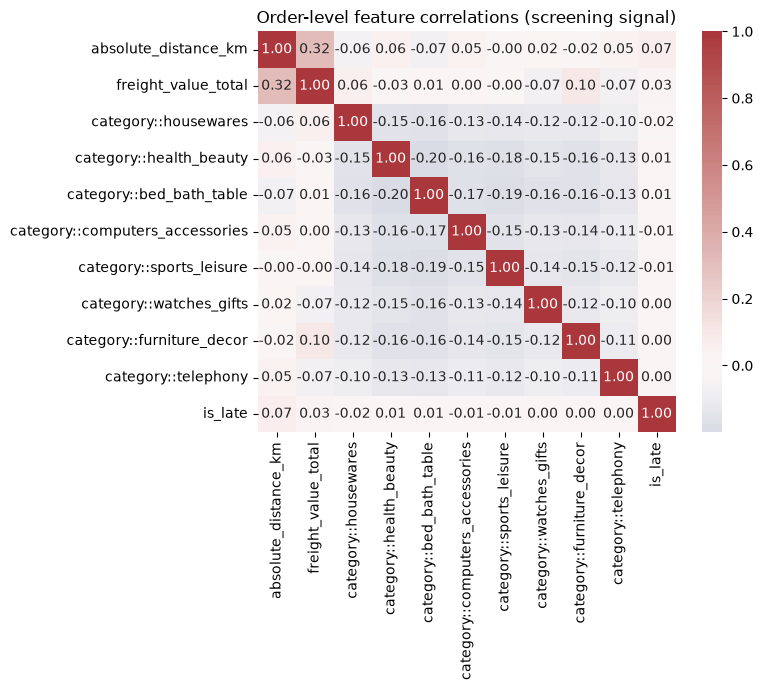

Route distance available for 96,000 of 96,476 comparable orders


In [3]:
from math import radians, sin, cos, asin, sqrt

def normalize_zip(values):
    return values.astype("string").str.replace(r"\.0$", "", regex=True).str.strip().str.zfill(5)

geo = geolocation.copy()
if "geolocation_zip_code_prefix" in geo.columns:
    geo_zip_column = "geolocation_zip_code_prefix"
elif "id" in geo.columns:
    geo_zip_column = "id"
else:
    raise KeyError("Geolocation API data must include a postal-code prefix or id column")
required_geo = {"geolocation_lat", "geolocation_lng"}
if not required_geo.issubset(geo.columns):
    raise KeyError(f"Geolocation API data is missing coordinate fields: {sorted(required_geo.difference(geo.columns))}")
geo["zip_prefix"] = normalize_zip(geo[geo_zip_column])
geo_centroids = geo.groupby("zip_prefix", as_index=False).agg(
    latitude=("geolocation_lat", "mean"), longitude=("geolocation_lng", "mean")
)

required_item_columns = {"order_id", "seller_id", "product_id", "freight_value"}
missing_item_columns = required_item_columns.difference(items.columns)
if missing_item_columns:
    raise KeyError(f"Items are missing required SLA feature fields: {sorted(missing_item_columns)}")
analysis_items = pd.merge(analysis, items, on="order_id", how="inner", validate="one_to_many")
item_columns = ["order_id", "seller_id", "product_id", "freight_value"]
item_detail = analysis_items[item_columns].merge(
    products[["product_id", "product_category_name"]].drop_duplicates("product_id"),
    on="product_id", how="left", validate="many_to_one"
)
if "category_translation" in raw_data:
    translation = raw_data["category_translation"]
    if {"product_category_name", "product_category_name_english"}.issubset(translation.columns):
        item_detail = item_detail.merge(
            translation[["product_category_name", "product_category_name_english"]].drop_duplicates("product_category_name"),
            on="product_category_name", how="left", validate="many_to_one"
        )
        item_detail["category_label"] = item_detail["product_category_name_english"].fillna(item_detail["product_category_name"])
    else:
        item_detail["category_label"] = item_detail["product_category_name"]
else:
    item_detail["category_label"] = item_detail["product_category_name"]

order_freight = item_detail.groupby("order_id")["freight_value"].sum(min_count=1).rename("freight_value_total")
top_categories = item_detail["category_label"].value_counts().head(8).index
category_presence = (
    item_detail.loc[item_detail["category_label"].isin(top_categories), ["order_id", "category_label"]]
    .drop_duplicates().assign(present=1)
    .pivot(index="order_id", columns="category_label", values="present")
    .fillna(0)
)
category_presence.columns = [f"category::{category}" for category in category_presence.columns]

if "customer_zip_code_prefix" not in customers.columns or "seller_zip_code_prefix" not in sellers.columns:
    raise KeyError("Customer and seller records must contain postal-code prefixes to estimate route distance")
customer_zip = customers[["customer_id", "customer_zip_code_prefix"]].drop_duplicates("customer_id").copy()
seller_zip = sellers[["seller_id", "seller_zip_code_prefix"]].drop_duplicates("seller_id").copy()
customer_zip["zip_prefix"] = normalize_zip(customer_zip["customer_zip_code_prefix"])
seller_zip["zip_prefix"] = normalize_zip(seller_zip["seller_zip_code_prefix"])
customer_coords = customer_zip.merge(geo_centroids, on="zip_prefix", how="left").rename(
    columns={"latitude": "customer_lat", "longitude": "customer_lng"}
)
seller_coords = seller_zip.merge(geo_centroids, on="zip_prefix", how="left").rename(
    columns={"latitude": "seller_lat", "longitude": "seller_lng"}
)
order_sellers = pd.merge(item_detail[["order_id", "seller_id"]].drop_duplicates(),
    analysis[["order_id", "customer_id"]], on="order_id", how="inner", validate="many_to_one"
).merge(customer_coords[["customer_id", "customer_lat", "customer_lng"]], on="customer_id", how="left").merge(
    seller_coords[["seller_id", "seller_lat", "seller_lng"]], on="seller_id", how="left"
)

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 6371.0088 * 2 * asin(sqrt(a))

valid_routes = order_sellers.dropna(subset=["customer_lat", "customer_lng", "seller_lat", "seller_lng"]).copy()
valid_routes["route_distance_km"] = valid_routes.apply(
    lambda row: haversine_km(row.customer_lat, row.customer_lng, row.seller_lat, row.seller_lng), axis=1
)
order_distance = valid_routes.groupby("order_id")["route_distance_km"].mean().rename("absolute_distance_km")

correlation_data = analysis.set_index("order_id")[["is_late"]].join(order_freight).join(category_presence).join(order_distance)
correlation_data["is_late"] = correlation_data["is_late"].astype(int)
candidate_features = [column for column in correlation_data.columns if column != "is_late"]
correlations = correlation_data[candidate_features].corrwith(correlation_data["is_late"]).dropna()
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)
display(correlations.rename("correlation_with_late").to_frame().round(3))

selected = correlations.head(12).index.tolist()
heatmap_columns = selected + ["is_late"]
plt.figure(figsize=(max(8, len(heatmap_columns) * 0.7), 7))
sns.heatmap(correlation_data[heatmap_columns].corr(), cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Order-level feature correlations (screening signal)")
plt.tight_layout()
plt.show()
print(f"Route distance available for {order_distance.notna().sum():,} of {len(analysis):,} comparable orders")

## 2. Seller and post-handoff accountability

Seller dispatch performance is measured using both approval-to-handoff duration and the signed gap between actual carrier handoff and `shipping_limit_date` (positive means handoff after the seller shipping limit). A volume threshold keeps tiny sellers from dominating rankings through unstable averages; adjust the threshold to the operational review policy.

The source has no carrier identifier or scan-level carrier events. Therefore, this notebook cannot assign transit delays to named carriers. It reports post-handoff transit by seller and seller-volume cohort as a diagnostic proxy: elevated transit across many sellers suggests a broad downstream problem, but it does not establish carrier accountability.

,order_count,avg_dispatch_days,avg_shipping_limit_gap_days,late_rate,avg_post_handoff_transit_days
seller_id,,,,,
54965bbe3e4f07ae045b90b0b8541f52,73,15.35,8.60,0.30,10.86
a49928bcdf77c55c6d6e05e09a9b4ca5,96,6.87,1.39,0.26,9.70
a7f13822ceb966b076af67121f87b063,73,10.54,1.18,0.07,11.54
88460e8ebdecbfecb5f9601833981930,246,7.55,0.25,0.20,9.99
827f8f69dfa529c561901c4f2e0f332f,91,5.51,-0.00,0.10,7.89
94144541854e298c2d976cb893b81343,68,5.24,-0.34,0.04,7.13
1ca7077d890b907f89be8c954a02686a,108,5.31,-0.34,0.22,9.91
2eb70248d66e0e3ef83659f71b244378,187,10.79,-0.51,0.14,6.85
8e6cc767478edae941d9bd9eb778d77a,100,5.94,-0.52,0.08,10.38


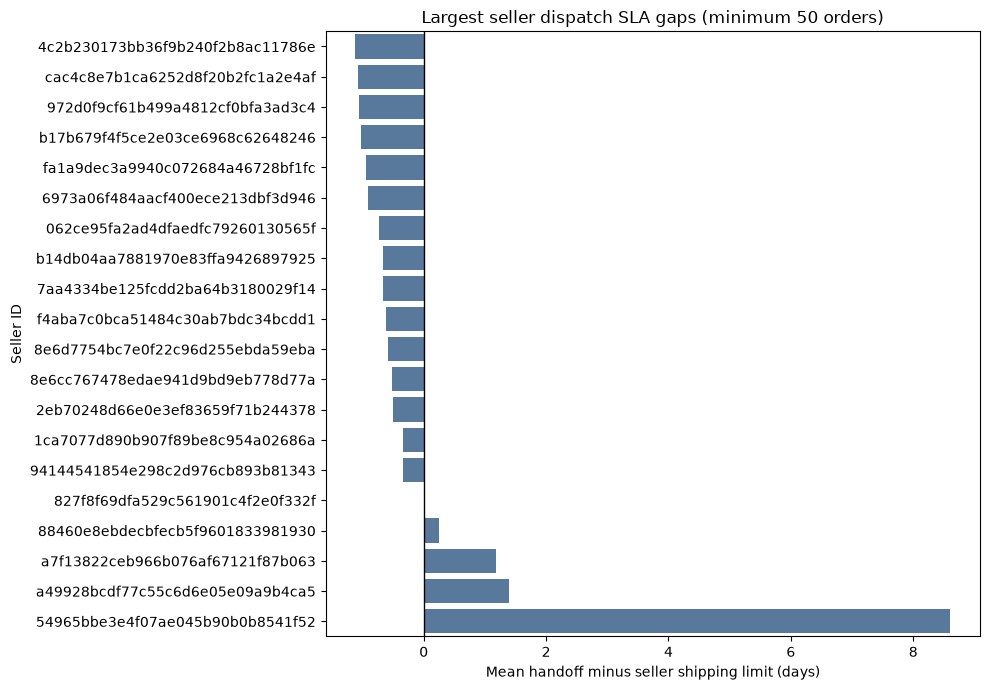

,sellers,mean_transit_days,median_transit_days
volume_band,,,
Volume quartile 1,107,9.21,9.04
Volume quartile 2,106,9.23,8.79
Volume quartile 3,106,9.06,8.89
Volume quartile 4,106,9.55,9.84


In [4]:
MIN_SELLER_ORDERS = 50
seller_order_items = pd.merge(
    analysis, items[["order_id", "seller_id", "shipping_limit_date"]],
    on="order_id", how="inner", validate="one_to_many"
)
seller_order_items["shipping_limit_date"] = pd.to_datetime(seller_order_items["shipping_limit_date"], errors="coerce")
seller_deadlines = seller_order_items[["order_id", "seller_id", "shipping_limit_date"]].copy()
seller_deadlines = seller_deadlines.groupby(["order_id", "seller_id"], as_index=False)["shipping_limit_date"].min()
dispatch_events = pd.merge(analysis[[
    "order_id", "order_approved_at", "order_delivered_carrier_date", "dispatch_days", "transit_days", "is_late"
]], seller_deadlines, on="order_id", how="inner", validate="one_to_many")
dispatch_events.loc[dispatch_events["dispatch_days"] < 0, "dispatch_days"] = np.nan
dispatch_events.loc[dispatch_events["transit_days"] < 0, "transit_days"] = np.nan
dispatch_events["dispatch_sla_gap_days"] = (
    dispatch_events["order_delivered_carrier_date"] - dispatch_events["shipping_limit_date"]
).dt.total_seconds() / 86400
seller_performance = dispatch_events.groupby("seller_id").agg(
    order_count=("order_id", "nunique"),
    avg_dispatch_days=("dispatch_days", "mean"),
    avg_shipping_limit_gap_days=("dispatch_sla_gap_days", "mean"),
    late_rate=("is_late", "mean"),
    avg_post_handoff_transit_days=("transit_days", "mean"),
).query("order_count >= @MIN_SELLER_ORDERS").sort_values(
    ["avg_shipping_limit_gap_days", "order_count"], ascending=[False, False]
)
display(seller_performance.head(20).round(2))

if not seller_performance.empty:
    plot_data = seller_performance.head(20).sort_values("avg_shipping_limit_gap_days")
    plt.figure(figsize=(10, 7))
    sns.barplot(data=plot_data, x="avg_shipping_limit_gap_days", y="seller_id", color="#4C78A8")
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Mean handoff minus seller shipping limit (days)")
    plt.ylabel("Seller ID")
    plt.title(f"Largest seller dispatch SLA gaps (minimum {MIN_SELLER_ORDERS} orders)")
    plt.tight_layout()
    plt.show()

seller_transit = seller_performance.dropna(subset=["avg_post_handoff_transit_days"]).reset_index()
if len(seller_transit) >= 2:
    seller_transit = seller_transit.assign(volume_band=pd.qcut(
        seller_transit["order_count"].rank(method="first"), q=min(4, len(seller_transit)),
        labels=[f"Volume quartile {i}" for i in range(1, min(4, len(seller_transit)) + 1)]
    ))
    display(seller_transit.groupby("volume_band", observed=True).agg(
        sellers=("seller_id", "nunique"), mean_transit_days=("avg_post_handoff_transit_days", "mean"),
        median_transit_days=("avg_post_handoff_transit_days", "median")
    ).round(2))

## Revenue at risk from late deliveries

Revenue at risk is the sum of recorded order payment values for orders delivered after the estimate. This is a gross merchandise/payment-value exposure indicator, not a refund, penalty, or recognized-revenue measure. Payment data may arrive as one row per payment or as an API `id`/nested `value` payload; the preparation below normalizes both forms before the required order-level merge.

In [5]:
payment_records = payments.copy()
if "order_id" not in payment_records.columns and "id" in payment_records.columns:
    payment_records = payment_records.rename(columns={"id": "order_id"})
if "payment_value" not in payment_records.columns and "value" in payment_records.columns:
    payment_records = payment_records.explode("value", ignore_index=True)
    payment_details = pd.json_normalize(payment_records["value"])
    payment_records = pd.concat(
        [payment_records.drop(columns=["value"]).reset_index(drop=True), payment_details.reset_index(drop=True)],
        axis=1,
    )
required_payment_columns = {"order_id", "payment_value"}
missing_payment_columns = required_payment_columns.difference(payment_records.columns)
if missing_payment_columns:
    raise KeyError(f"Payment data is missing required fields: {sorted(missing_payment_columns)}")
payment_records["payment_value"] = pd.to_numeric(payment_records["payment_value"], errors="coerce")
payment_by_order = payment_records.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum")
)
orders_with_payments = pd.merge(
    analysis[["order_id", "is_late"]], payment_by_order, on="order_id", how="inner", validate="one_to_one"
)
late_payment_orders = orders_with_payments.loc[orders_with_payments["is_late"]]
total_observed_payments = orders_with_payments["payment_value"].sum()
revenue_at_risk = late_payment_orders["payment_value"].sum()
revenue_at_risk_pct = revenue_at_risk / total_observed_payments * 100 if total_observed_payments else 0
revenue_at_risk_summary = pd.DataFrame({
    "Metric": ["Orders with payment data", "Late orders with payment data", "Revenue at risk", "Revenue at risk (% of matched payment value)"],
    "Value": [len(orders_with_payments), len(late_payment_orders), revenue_at_risk, revenue_at_risk_pct],
})
display(revenue_at_risk_summary)

,Metric,Value
0,Orders with payment data,9.647500e+04
1,Late orders with payment data,7.826000e+03
2,Revenue at risk,1.351691e+06
3,Revenue at risk (% of matched payment value),8.764788e+00


## 3. Temporal seasonality and day-of-week bottlenecks

The heatmap compares average approval and dispatch duration by local source timestamp weekday. Since timezone metadata is not included, weekday labels inherit the source timestamp convention and should not be interpreted as a verified local-time effect. Differences can also reflect order mix or staffing calendars; use the pattern to target follow-up, not to infer that weekend ordering causes delay.

,orders,mean_approval_days,mean_dispatch_days
purchase_weekday,,,
Monday,15703,0.38,2.39
Tuesday,15502,0.37,2.53
Wednesday,15074,0.35,2.68
Thursday,14322,0.36,3.04
Friday,13685,0.56,3.72
Saturday,10556,0.60,3.33
Sunday,11634,0.45,2.45


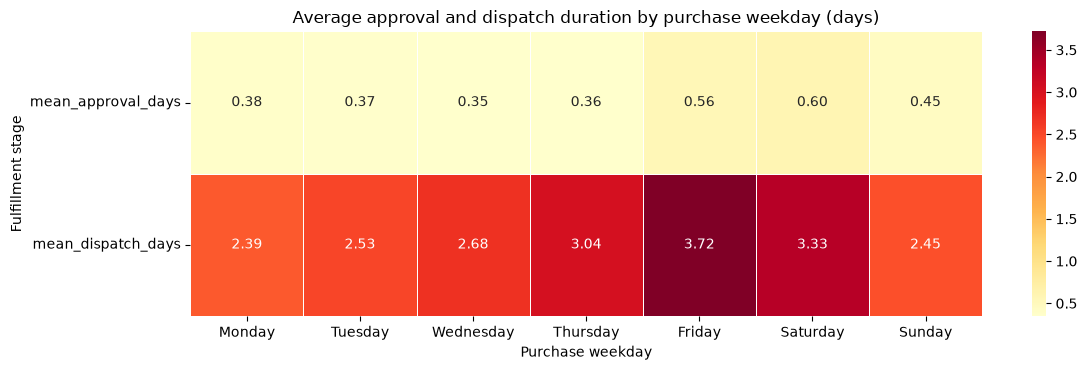

In [6]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
temporal = analysis.dropna(subset=["order_purchase_timestamp"]).copy()
temporal["purchase_weekday"] = pd.Categorical(
    temporal["order_purchase_timestamp"].dt.day_name(), categories=weekday_order, ordered=True
)
for column in ["approval_days", "dispatch_days"]:
    temporal.loc[temporal[column] < 0, column] = np.nan
weekday_stage = temporal.groupby("purchase_weekday", observed=False).agg(
    orders=("order_id", "nunique"), mean_approval_days=("approval_days", "mean"),
    mean_dispatch_days=("dispatch_days", "mean")
)
display(weekday_stage.round(2))
heatmap_data = weekday_stage[["mean_approval_days", "mean_dispatch_days"]].T
plt.figure(figsize=(12, 3.8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.xlabel("Purchase weekday")
plt.ylabel("Fulfillment stage")
plt.title("Average approval and dispatch duration by purchase weekday (days)")
plt.tight_layout()
plt.show()

## 4. Geospatial volatility: last-mile predictability by state

For each customer state, compare mean delivery delay relative to the estimated date with the standard deviation of end-to-end delivery duration. A state can have a modest mean delay but high duration variability, making the promise unreliable. Marker size reflects cohort volume; the minimum sample-size guard reduces noisy small-state comparisons. Customer state is the delivery-region proxy in this dataset, not a precise route or carrier lane.

,orders,mean_delivery_days,delivery_time_std_days,mean_delay_days,late_rate
customer_state,,,,,
SE,335,21.52,16.76,-9.33,0.15
PI,476,19.46,14.72,-10.63,0.16
AM,145,26.43,13.86,-18.85,0.04
PA,946,23.77,13.15,-13.39,0.12
CE,1279,21.27,13.13,-10.11,0.15
RN,474,19.28,12.99,-12.96,0.11
BA,3256,19.34,11.69,-10.10,0.14
RJ,12353,15.31,11.52,-11.06,0.13
AL,397,24.54,11.48,-8.03,0.24


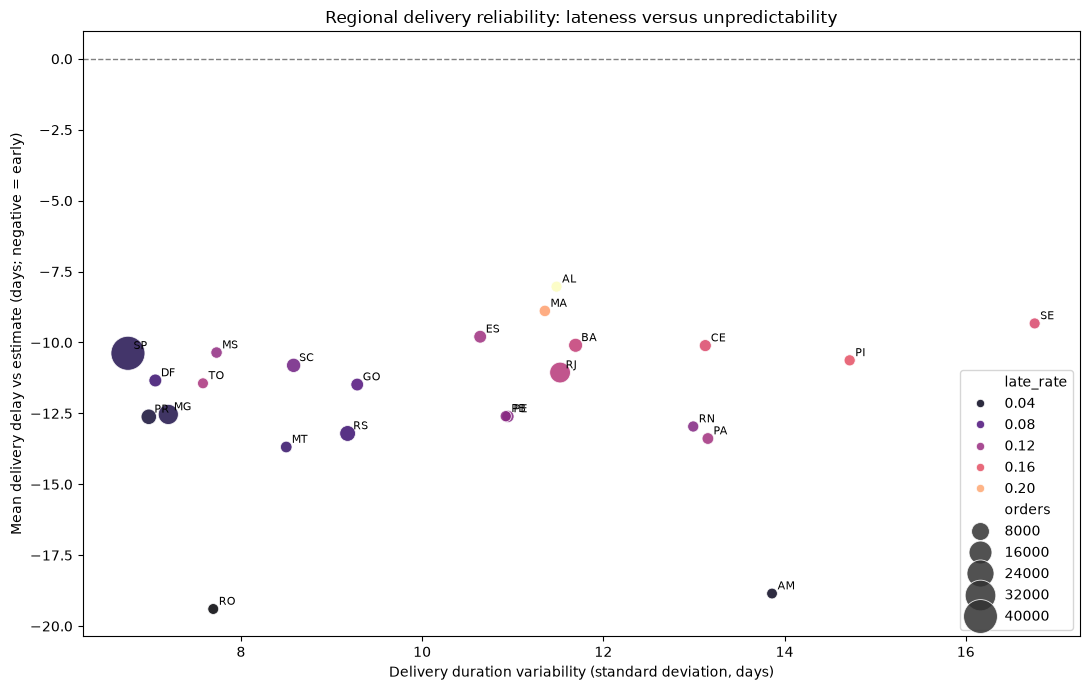

In [7]:
if not {"customer_id", "customer_state"}.issubset(customers.columns):
    raise KeyError("Customer table must contain customer_id and customer_state for regional analysis")
state_orders = analysis.merge(
    customers[["customer_id", "customer_state"]].drop_duplicates("customer_id"),
    on="customer_id", how="left", validate="many_to_one"
).dropna(subset=["customer_state", "delivery_days", "delay_days"])
regional = state_orders.groupby("customer_state").agg(
    orders=("order_id", "nunique"),
    mean_delivery_days=("delivery_days", "mean"),
    delivery_time_std_days=("delivery_days", "std"),
    mean_delay_days=("delay_days", "mean"),
    late_rate=("is_late", "mean"),
).query("orders >= 100").sort_values("delivery_time_std_days", ascending=False)
display(regional.round(2))

if not regional.empty:
    plt.figure(figsize=(11, 7))
    ax = sns.scatterplot(
        data=regional.reset_index(), x="delivery_time_std_days", y="mean_delay_days",
        size="orders", sizes=(60, 600), hue="late_rate", palette="magma", alpha=0.85
    )
    for state, row in regional.iterrows():
        ax.annotate(state, (row["delivery_time_std_days"], row["mean_delay_days"]), xytext=(4, 3), textcoords="offset points", fontsize=8)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_xlabel("Delivery duration variability (standard deviation, days)")
    ax.set_ylabel("Mean delivery delay vs estimate (days; negative = early)")
    ax.set_title("Regional delivery reliability: lateness versus unpredictability")
    plt.tight_layout()
    plt.show()
else:
    print("No states meet the 100-order minimum for a stable regional comparison.")

## Interpretation and next operational actions

- Investigate the strongest correlation signals with controlled comparisons (for example, within state and month) before changing policy.
- Prioritize sellers with material volume and a positive average handoff-versus-shipping-limit gap; review individual orders and fulfillment practices before escalation.
- If transit duration is elevated across seller-volume bands, request carrier-level tracking events, carrier IDs, and lane-level data to isolate the downstream bottleneck.
- Review weekday heatmap peaks with staffing and cut-off calendars, and use high-variance regions to improve promise buffers or delivery communications.

This is a retrospective batch analysis. Correlation, postal-code centroid distance, seller-to-carrier inference, timestamp timezone assumptions, and sample selection are explicit limitations; none of these results proves causality.